<a href="https://colab.research.google.com/github/GouriRajkarne/Electric-Vehicle-Battery-Life-Prediction/blob/main/Electric%20Vehicle%20Battery%20Life%20Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Electric Vehicle Battery Life Prediction

## 1. Import Libraries

In [1]:
import pandas as pd

# keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

# sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler,LabelEncoder

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
path = "/content/drive/MyDrive/metadata.csv"
import pandas as pd

df = pd.read_csv(path)
df.head()

,type,start_time,ambient_temperature,battery_id,test_id,uid,filename,Capacity,Re,Rct
0,discharge,[2010. 7. 21. 15. 0. ...,4,B0047,0,1,00001.csv,1.6743047446975208,NaN,NaN
1,impedance,[2010. 7. 21. 16. 53. ...,24,B0047,1,2,00002.csv,NaN,0.05605783343888099,0.20097016584458333
2,charge,[2010. 7. 21. 17. 25. ...,4,B0047,2,3,00003.csv,NaN,NaN,NaN
3,impedance,[2010 7 21 20 31 5],24,B0047,3,4,00004.csv,NaN,0.05319185850921101,0.16473399914864734
4,discharge,[2.0100e+03 7.0000e+00 2.1000e+01 2.1000e+01 2...,4,B0047,4,5,00005.csv,1.5243662105099023,NaN,NaN


## 2. Data Preprocessing

In [4]:
df = df.drop(columns=['start_time','battery_id','test_id','uid','filename'])
df

,type,ambient_temperature,Capacity,Re,Rct
0,discharge,4,1.6743047446975208,NaN,NaN
1,impedance,24,NaN,0.05605783343888099,0.20097016584458333
2,charge,4,NaN,NaN,NaN
3,impedance,24,NaN,0.05319185850921101,0.16473399914864734
4,discharge,4,1.5243662105099023,NaN,NaN
...,...,...,...,...,...
7560,impedance,24,NaN,0.0968087979207628,0.15489738203707232
7561,discharge,4,1.0201379996149256,NaN,NaN
7562,charge,4,NaN,NaN,NaN
7563,discharge,4,0.9907591663373165,NaN,NaN


In [5]:
# Converting 'Re', 'Rct', and 'Capacity' to numeric, invalid parsing will be set to NaN
df['Re'] = pd.to_numeric(df['Re'], errors='coerce')
df['Rct'] = pd.to_numeric(df['Rct'], errors='coerce')
df['Capacity'] = pd.to_numeric(df['Capacity'], errors='coerce')

# Fill missing values in 'Re', 'Rct', and 'Capacity' with their respective means
df['Re'].fillna(df['Re'].mean(), inplace=True)
df['Rct'].fillna(df['Rct'].mean(), inplace=True)
df['Capacity'].fillna(df['Capacity'].mean(), inplace=True)

df.head()

/tmp/ipykernel_3271/1552743652.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Re'].fillna(df['Re'].mean(), inplace=True)
/tmp/ipykernel_3271/1552743652.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try us

,type,ambient_temperature,Capacity,Re,Rct
0,discharge,4,1.674305,-4.976500e+11,1.055903e+12
1,impedance,24,1.326543,5.605783e-02,2.009702e-01
2,charge,4,1.326543,-4.976500e+11,1.055903e+12
3,impedance,24,1.326543,5.319186e-02,1.647340e-01
4,discharge,4,1.524366,-4.976500e+11,1.055903e+12


## 3. Encoding

In [6]:
label_encoder = LabelEncoder()
df['type'] = label_encoder.fit_transform(df['type'])

In [31]:
df.head()

,type,ambient_temperature,Capacity,Re,Rct
0,1,4,1.674305,-4.976500e+11,1.055903e+12
1,2,24,1.326543,5.605783e-02,2.009702e-01
2,0,4,1.326543,-4.976500e+11,1.055903e+12
3,2,24,1.326543,5.319186e-02,1.647340e-01
4,1,4,1.524366,-4.976500e+11,1.055903e+12


## 4. Train Test Split

In [7]:
# Features (X) - All columns except 'ambient_temperature'
X = df.drop(columns=['ambient_temperature'])

# Target (y) - 'ambient_temperature' column
y = df['ambient_temperature']

# Spliting the data into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Shapes of the split data
print(f'X_train shape: {X_train.shape}')
print(f'X_test shape: {X_test.shape}')

X_train shape: (6052, 4)
X_test shape: (1513, 4)


## 5. Scaling

In [8]:
scaler = MinMaxScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f'Scaled X_train: \n{X_train_scaled[:5]}')

Scaled X_train: 
[[1.00000000e+00 5.02450122e-01 9.99999999e-01 1.98111482e-10]
 [5.00000000e-01 4.55998175e-01 0.00000000e+00 1.00000000e+00]
 [5.00000000e-01 3.60527766e-02 0.00000000e+00 1.00000000e+00]
 [0.00000000e+00 5.02450122e-01 0.00000000e+00 1.00000000e+00]
 [5.00000000e-01 5.35874070e-01 0.00000000e+00 1.00000000e+00]]


## 6. Model Building

In [10]:
# Simple Multi-Layer Perceptron Model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

mlp_model = Sequential()

# Input layer and a single hidden layer with 32 units and ReLU activation
mlp_model.add(Dense(units=32, activation='relu', input_dim=X_train_scaled.shape[1]))

# Output layer with 1 unit (for regression output), using a linear activation
mlp_model.add(Dense(units=1, activation='linear'))

# Compile the model with Adam optimizer and Mean Squared Error loss
mlp_model.compile(optimizer='adam', loss='mean_squared_error')

# Summary of the simple MLP model architecture
mlp_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 32)             │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 193 (772.00 B)

 Trainable params: 193 (772.00 B)

 Non-trainable params: 0 (0.00 B)

In [11]:
history = mlp_model.fit(X_train_scaled, y_train, epochs=50, batch_size=32, validation_data=(X_test_scaled, y_test))

Epoch 1/50
190/190 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 421.1935 - val_loss: 10682.1670
Epoch 2/50
190/190 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 199.2645 - val_loss: 16189.2861
Epoch 3/50
190/190 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 114.3799 - val_loss: 12852.1094
Epoch 4/50
190/190 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 109.1137 - val_loss: 8196.7812
Epoch 5/50
190/190 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 108.1345 - val_loss: 4437.0332
Epoch 6/50
190/190 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 107.1770 - val_loss: 2226.5818
Epoch 7/50
190/190 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 106.1401 - val_loss: 967.8934
Epoch 8/50
190/190 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 105.1545 - val_loss: 227.5071
Epoch 9/50
190/190 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 104.1495 - val_loss: 137.9527
Epoch 10/50
190/190 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 103.1803 - val_loss: 645.8015
Epoch 11/50
190/190 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 102.2845 - val_loss: 1438.468

In [12]:
model = Sequential()

# Input layer and first hidden layer with 64 units and ReLU activation
model.add(Dense(units=64, activation='relu', input_dim=X_train_scaled.shape[1]))

# Add Dropout layer with 0.2 rate (20% dropout)
model.add(Dropout(0.2))

# Second hidden layer with 32 units and ReLU activation
model.add(Dense(units=32, activation='relu'))

# Add another Dropout layer
model.add(Dropout(0.2))

# Output layer with 1 unit (for regression output), using a linear activation
model.add(Dense(units=1, activation='linear'))

# Compile the model with Adam optimizer and Mean Squared Error loss (for regression)
model.compile(optimizer='adam', loss='mean_squared_error')

# Summary of the model architecture
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                 │ (None, 64)             │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,433 (9.50 KB)

 Trainable params: 2,433 (9.50 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:
history2 = model.fit(X_train_scaled, y_train, epochs=50, batch_size=32, validation_data=(X_test_scaled, y_test))

Epoch 1/50
190/190 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 274.0330 - val_loss: 77576.7969
Epoch 2/50
190/190 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 117.4327 - val_loss: 32270.8613
Epoch 3/50
190/190 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 112.3779 - val_loss: 17874.8789
Epoch 4/50
190/190 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 110.0339 - val_loss: 4457.5415
Epoch 5/50
190/190 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 107.7600 - val_loss: 269.8056
Epoch 6/50
190/190 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 105.1325 - val_loss: 168.2743
Epoch 7/50
190/190 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 103.3764 - val_loss: 900.8547
Epoch 8/50
190/190 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 103.0935 - val_loss: 1378.3713
Epoch 9/50
190/190 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 101.4811 - val_loss: 1551.1732
Epoch 10/50
190/190 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 100.5117 - val_loss: 1714.5474
Epoch 11/50
190/190 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 101.3460 - val_loss: 1762.23

In [14]:
# More Complex Sequential Model
model2 = Sequential()

# Input layer and first hidden layer with 128 units and ReLU activation
model2.add(Dense(units=128, activation='relu', input_dim=X_train_scaled.shape[1]))

# Add Dropout layer with 0.3 rate (30% dropout)
model2.add(Dropout(0.3))

# Second hidden layer with 64 units and ReLU activation
model2.add(Dense(units=64, activation='relu'))

# Add another Dropout layer
model2.add(Dropout(0.3))

# Third hidden layer with 32 units and ReLU activation
model2.add(Dense(units=32, activation='relu'))

# Output layer with 1 unit (for regression output), using a linear activation
model2.add(Dense(units=1, activation='linear'))

# Compile the model with Adam optimizer and Mean Squared Error loss (for regression)
model2.compile(optimizer='adam', loss='mean_squared_error')

# Summary of the model architecture
model2.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 128)            │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,009 (43.00 KB)

 Trainable params: 11,009 (43.00 KB)

 Non-trainable params: 0 (0.00 B)

In [15]:
history3 = model2.fit(X_train_scaled, y_train, epochs=50, batch_size=32, validation_data=(X_test_scaled, y_test))

Epoch 1/50
190/190 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 186.7939 - val_loss: 61221.8906
Epoch 2/50
190/190 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 109.4057 - val_loss: 40997.7695
Epoch 3/50
190/190 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 106.3195 - val_loss: 38140.7422
Epoch 4/50
190/190 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 100.6028 - val_loss: 30409.5898
Epoch 5/50
190/190 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 99.1199 - val_loss: 25537.3516
Epoch 6/50
190/190 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 97.7589 - val_loss: 19930.0977
Epoch 7/50
190/190 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 95.1841 - val_loss: 18551.5352
Epoch 8/50
190/190 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 93.0963 - val_loss: 18529.2910
Epoch 9/50
190/190 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 93.1211 - val_loss: 14330.8477
Epoch 10/50
190/190 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 91.6462 - val_loss: 11702.3525
Epoch 11/50
190/190 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 91.0616 - val_loss: 8177

## 7. Model Evaluation

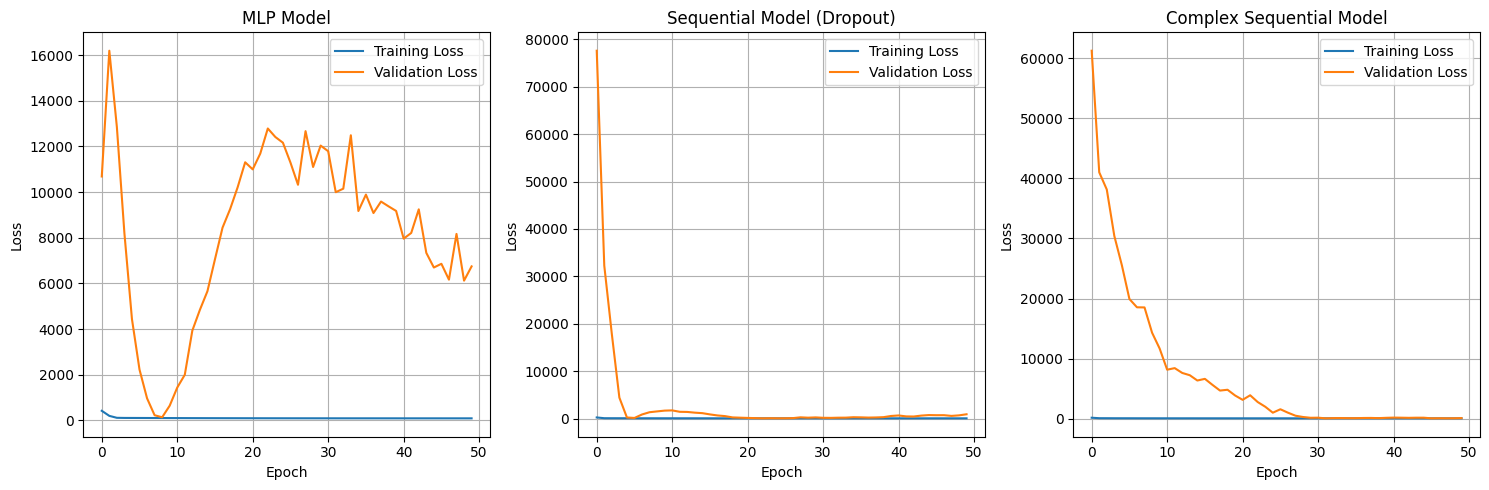

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('MLP Model')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 3, 2)
plt.plot(history2.history['loss'], label='Training Loss')
plt.plot(history2.history['val_loss'], label='Validation Loss')
plt.title('Sequential Model (Dropout)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 3, 3)
plt.plot(history3.history['loss'], label='Training Loss')
plt.plot(history3.history['val_loss'], label='Validation Loss')
plt.title('Complex Sequential Model')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [25]:
from sklearn.metrics import mean_squared_error

y_pred_mlp = mlp_model.predict(X_test_scaled)
mse_mlp = mean_squared_error(y_test, y_pred_mlp)

print(f'MLP Model (mlp_model) Mean Squared Error: {mse_mlp:.2f}')

y_pred_model = model.predict(X_test_scaled)
mse_model = mean_squared_error(y_test, y_pred_model)

print(f'Sequential Model (model) Mean Squared Error: {mse_model:.2f}')

y_pred_model2 = model2.predict(X_test_scaled)
mse_model2 = mean_squared_error(y_test, y_pred_model2)

print(f'Complex Sequential Model (model2) Mean Squared Error: {mse_model2:.2f}')

48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
MLP Model (mlp_model) Mean Squared Error: 6745.18
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
Sequential Model (model) Mean Squared Error: 945.94
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Complex Sequential Model (model2) Mean Squared Error: 126.73


## 8. Prediction

In [26]:
import numpy as np

def predict_battery_life(type_discharge, Capacity, Re, Rct, label_encoder, scaler, model2):

    type_discharge_encoded = label_encoder.transform([type_discharge])[0]
    X_input = np.array([[type_discharge_encoded,Capacity, Re, Rct]])
    X_input_scaled = scaler.transform(X_input)
    predicted_battery_life = model2.predict(X_input_scaled)

    return predicted_battery_life[0][0]

In [27]:
type_discharge = 'discharge'
Capacity = 1.674305
Re = -4.976500e+11
Rct = 1.055903e+12

predicted_battery_life = predict_battery_life(type_discharge, Capacity, Re, Rct, label_encoder, scaler, model2)

print(f"Predicted Battery Life: {predicted_battery_life}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
Predicted Battery Life: 25.06846809387207


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


In [29]:
type_discharge = 'charge'
Capacity = 20.5
Re = -2.983215e+11
Rct = 1.223456e+12

predicted_battery_life = predict_battery_life(type_discharge, Capacity, Re, Rct, label_encoder, scaler, model)
print(f"Predicted Battery Life: {predicted_battery_life}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
Predicted Battery Life: 423.72076416015625


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
